In [1]:
#multiple linear regression 

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
data = {
    'Size': [1000, 1500, 2000, 2500, 3000],      # Size in square feet
    'Bedrooms': [2, 3, 3, 4, 5],               # Number of bedrooms
    'Age': [20, 15, 10, 5, 2],                 # Age of house in years
    'Price': [200000, 250000, 300000, 350000, 400000]  # House price
}

# Convert dictionary into DataFrame
df = pd.DataFrame(data)

# Show dataset
print("Dataset:")
print(df)

Dataset:
   Size  Bedrooms  Age   Price
0  1000         2   20  200000
1  1500         3   15  250000
2  2000         3   10  300000
3  2500         4    5  350000
4  3000         5    2  400000


In [4]:
# X = Independent variables (inputs)
X = df[['Size', 'Bedrooms', 'Age']]

# Y = Dependent variable (output)
Y = df['Price']

In [5]:
# Create Linear Regression Model
model = LinearRegression()

In [6]:
#train the model
model.fit(X, Y)

LinearRegression()

In [7]:
# S Make Predictions


predictions = model.predict(X)

print("\nPredicted Prices:")
print(predictions)


Predicted Prices:
[200000. 250000. 300000. 350000. 400000.]


In [11]:
print("\nIntercept (b0):", model.intercept_)
print("Coefficients (b1, b2, b3):", model.coef_)


Intercept (b0): 99999.99999999953
Coefficients (b1, b2, b3): [ 1.00000000e+02 -2.30086819e-11  1.72569964e-11]


In [ ]:
#  Check Model Accuracy


# R2 Score (how good the model is)
r2 = r2_score(Y, predictions)
print("\nR2 Score:", r2)
# R² Score
# Between 0 and 1
# Closer to 1 → Good model
# Example: 0.95 = 95% accuracy


R2 Score: 1.0


In [14]:
# Mean Squared Error (error measurement)
mse = mean_squared_error(Y, predictions)
print("Mean Squared Error:", mse)
# MSE
# Lower value → Better model

mae=mean_squared_error(Y,predictions)
print("Mean Absolute error",mae)



Mean Squared Error: 8.470329472543003e-22
Mean Absolute error 8.470329472543003e-22


In [10]:
# Step 9: Predict New House Price
new_house = np.array([[2200, 4, 8]])

new_prediction = model.predict(new_house)

print("\nPredicted Price for New House:", new_prediction[0])


Predicted Price for New House: 320000.0


c:\Users\Infra\miniconda3\envs\sum25\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


c:\Users\Infra\miniconda3\envs\sum25\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


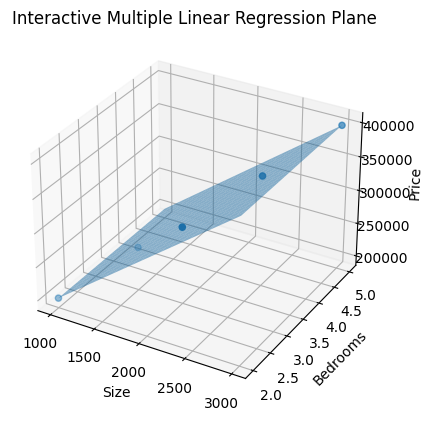

In [17]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
# Create meshgrid
size_range = np.linspace(df['Size'].min(), df['Size'].max(), 20)
bedroom_range = np.linspace(df['Bedrooms'].min(), df['Bedrooms'].max(), 20)
size_grid, bedroom_grid = np.meshgrid(size_range, bedroom_range)

age_mean = df['Age'].mean()

price_grid = model.predict(
    np.c_[size_grid.ravel(), bedroom_grid.ravel(), np.full(size_grid.size, age_mean)]
)

price_grid = price_grid.reshape(size_grid.shape)

# Enable interactive mode
plt.ion()

# Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(size_grid, bedroom_grid, price_grid, alpha=0.5)
ax.scatter(df['Size'], df['Bedrooms'], df['Price'])

ax.set_xlabel('Size')
ax.set_ylabel('Bedrooms')
ax.set_zlabel('Price')

plt.title("Interactive Multiple Linear Regression Plane")
plt.show()